In [9]:
from copy import deepcopy
import h5py
import numpy as np
import scipy as sp
from scipy.sparse.linalg import norm
import matplotlib.pyplot as plt
import openfermion as of
from openfermionpyscf import run_pyscf
import qiskit
from quimb.tensor import MPS_rand_state
from quimb_tebd import (
    pauli_sum_to_mpo, get_drmg_ground_state, trotter_circuit_from_psum,
    energy_vs_d, get_evolved_states, fill_subspace_matrices_mps,
    exact_evolved_states, mps_to_vector, fill_subspace_matrices_vectors
)

In [3]:
molec = "BeH2"
basis = "sto-3g"
n_elec = 6
geometry = of.chem.geometry_from_pubchem(molec)
multiplicity = 1
dmrg_max_bond = [4, 6, 8]
tebd_max_bond = [8, 9, 10]
mpo_max_bond = 500
steps = 10
eps = 1e-12
d = 20

In [4]:
# Get the Hamiltonian.
molecule = of.chem.MolecularData(
    geometry, basis, multiplicity
)
molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
print(f"HF energy:", molecule.hf_energy)
print(f"FCI energy:", molecule.fci_energy)
hamiltonian = molecule.get_molecular_hamiltonian()
hamiltonian_qubop = of.transforms.jordan_wigner(hamiltonian)
hamiltonian_psum = of.transforms.qubit_operator_to_pauli_sum(hamiltonian_qubop)
ham_sparse = of.linalg.get_sparse_operator(hamiltonian_qubop)
qs = hamiltonian_psum.qubits
print("nq=", len(qs))
hamiltonian_mpo = pauli_sum_to_mpo(hamiltonian_psum, qs, mpo_max_bond)

HF energy: -14.443241148489246
FCI energy: -14.472947415601425
nq= 14


In [5]:
ham_norm = norm(ham_sparse)
tau = np.pi / ham_norm
print(f"tau = {tau:4.5e}")

tau = 3.21087e-03


In [6]:
# Run DMRG
ground_states = []
dmrg_energies = []
for i, chi_dmrg in enumerate(dmrg_max_bond):
    ground_state, energy, number = get_drmg_ground_state(hamiltonian_mpo, n_elec, chi_dmrg, alpha=1e-8)
    ground_states.append(ground_state.copy())
    dmrg_energies.append(energy)
    print(f"DMRG ground state has energy {energy} and occupation {number}.")
    fci_err = abs(molecule.fci_energy - energy)
    print(f"FCI absolute error: {fci_err:4.5e}")

DMRG ground state has energy -14.460568263081674 and occupation 6.000004195376584.
FCI absolute error: 1.23792e-02
DMRG ground state has energy -14.469859624890281 and occupation 6.000000196033138.
FCI absolute error: 3.08779e-03
DMRG ground state has energy -14.471830764355646 and occupation 6.000000052607859.
FCI absolute error: 1.11665e-03


In [18]:
ev_circuit = trotter_circuit_from_psum(hamiltonian_psum, tau, steps)
ev_circuit_transpiled = qiskit.transpile(ev_circuit, basis_gates=["u3", "cx"])

krylov_energies = np.zeros((len(tebd_max_bond), d-1), dtype=float)
krylov_num_kept = np.zeros((len(tebd_max_bond), d-1), dtype=float)
rand_state = MPS_rand_state(len(ground_states[0].tensors), 5)
ref_state = 0.1 * ground_states[0].copy() + 1.0 * rand_state
ref_state = ref_state / ref_state.norm()
for i, chi_tebd in enumerate(tebd_max_bond):
    print(f"chi = {chi_tebd}")
    states = get_evolved_states(ev_circuit_transpiled, ref_state, d, chi_tebd, None)
    h, s = fill_subspace_matrices_mps(states, hamiltonian_mpo)
    energies, num_kept = energy_vs_d(h, s, method="threshold", eps=eps)
    krylov_energies[i, :] = deepcopy(energies)
    krylov_num_kept[i, :] = deepcopy(num_kept)

chi = 8
chi = 9
chi = 10


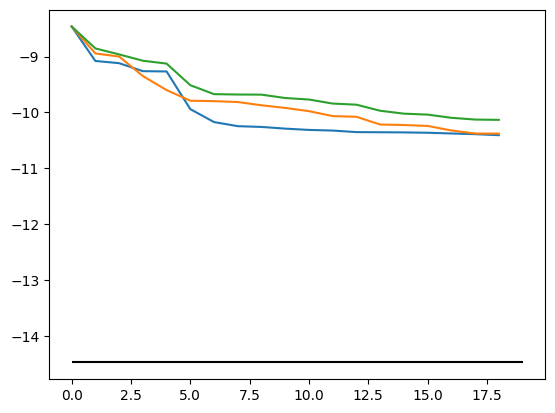

In [19]:
fig, ax = plt.subplots()
for i, chi_tebd in enumerate(tebd_max_bond):
    ax.plot(krylov_energies[i, :], label=f"TEBD chi = {chi_tebd}")
ax.hlines(molecule.fci_energy, 0., len(krylov_energies[0, :]), color='k')
#ax.plot(energies_u)

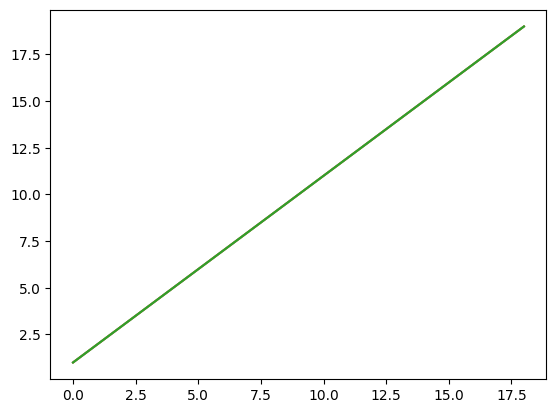

In [20]:
fig2, ax2 = plt.subplots()
ax2.plot(krylov_num_kept.T)

In [21]:
for i, state in enumerate(states):
    fidelity = abs(state.H @ states[0]) ** 2
    print(f"i={i} fidelity={fidelity:4.5e}")

i=0 fidelity=1.00000e+00
i=1 fidelity=7.33110e-01
i=2 fidelity=7.25959e-01
i=3 fidelity=7.24113e-01
i=4 fidelity=7.22706e-01
i=5 fidelity=7.21484e-01
i=6 fidelity=7.20390e-01
i=7 fidelity=7.19377e-01
i=8 fidelity=7.18416e-01
i=9 fidelity=7.17480e-01
i=10 fidelity=7.16541e-01
i=11 fidelity=7.15576e-01
i=12 fidelity=7.14571e-01
i=13 fidelity=7.13518e-01
i=14 fidelity=7.12410e-01
i=15 fidelity=7.11244e-01
i=16 fidelity=7.10019e-01
i=17 fidelity=7.08733e-01
i=18 fidelity=7.07385e-01
i=19 fidelity=7.05977e-01
